In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/data

In [2]:
data = pd.read_csv("Mall_Customers.csv", sep = ",")
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
data.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
data.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

<Axes: xlabel='Age', ylabel='Count'>

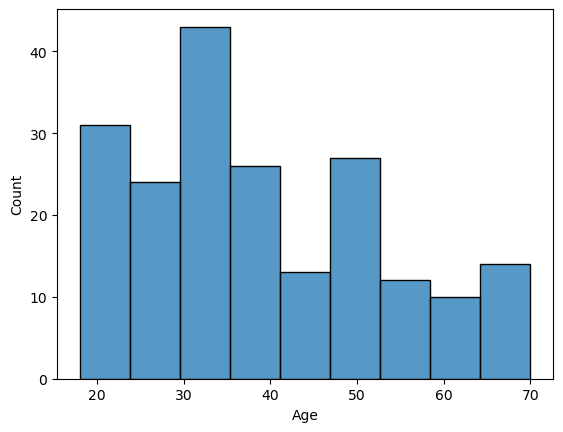

In [5]:
sns.histplot(data["Age"])

<Axes: xlabel='Annual Income (k$)', ylabel='Count'>

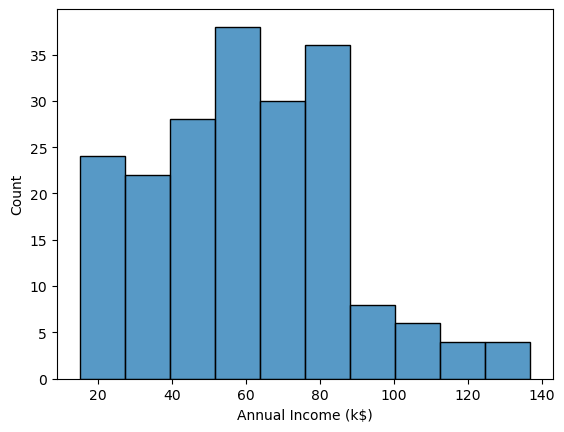

In [7]:
sns.histplot(data["Annual Income (k$)"])

<Axes: xlabel='Spending Score (1-100)', ylabel='Count'>

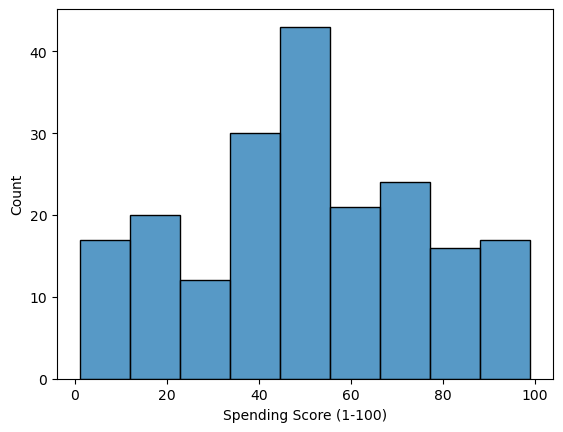

In [9]:
sns.histplot(data["Spending Score (1-100)"])

<Axes: xlabel='Gender', ylabel='count'>

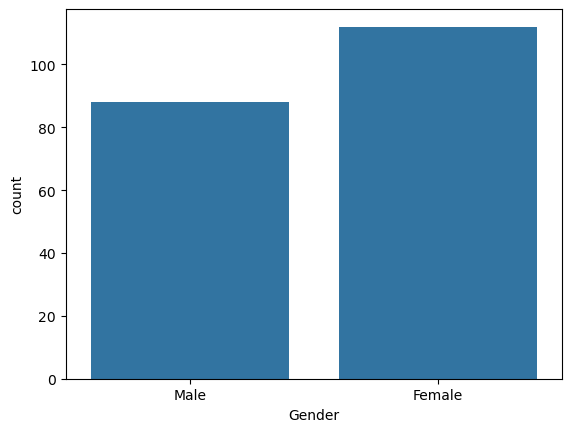

In [10]:
sns.countplot(x = data["Gender"])

In [14]:
data.iloc[:,2:].corr(numeric_only = True)

,Age,Annual Income (k$),Spending Score (1-100)
Age,1.000000,-0.012398,-0.327227
Annual Income (k$),-0.012398,1.000000,0.009903
Spending Score (1-100),-0.327227,0.009903,1.000000


In [17]:
data_num = data.iloc[:,2:]
data_normalizada = (data_num - data_num.min()) / (data_num.max() - data_num.min())
data_normalizada.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,0.019231,0.000000,0.387755
1,0.057692,0.000000,0.816327
2,0.038462,0.008197,0.051020
3,0.096154,0.008197,0.775510
4,0.250000,0.016393,0.397959


In [20]:
data_copy = data_normalizada.copy()
data_copy = data_normalizada[["Age", "Annual Income (k$)"]]
data_copy

,Age,Annual Income (k$)
0,0.019231,0.000000
1,0.057692,0.000000
2,0.038462,0.008197
3,0.096154,0.008197
4,0.250000,0.016393
...,...,...
195,0.326923,0.860656
196,0.519231,0.909836
197,0.269231,0.909836
198,0.269231,1.000000


In [25]:
acum = []
for i in range(1,11):
    modelo = KMeans(
        n_clusters = i,
        n_init = 10, 
        max_iter = 300 
    )
    modelo.fit(data_copy)
    acum.append([i, modelo.inertia_])

C:\DanielaLopez\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\DanielaLopez\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\DanielaLopez\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\DanielaLopez\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chun

<Axes: >

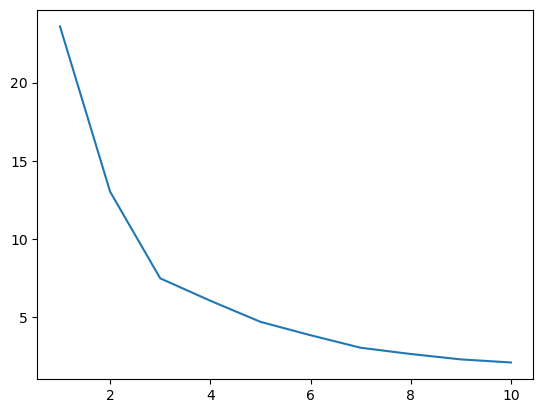

In [26]:
sns.lineplot(x = np.array(acum)[:,0], y = np.array(acum)[:, 1])

In [27]:
modelo = KMeans(
    n_clusters = 3,
    n_init = 10, 
    max_iter = 300 
)
modelo.fit(data_copy)

C:\DanielaLopez\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, n_init=10)

In [28]:
data_copy["cluster"] = modelo.labels_

<Axes: xlabel='Age', ylabel='Annual Income (k$)'>

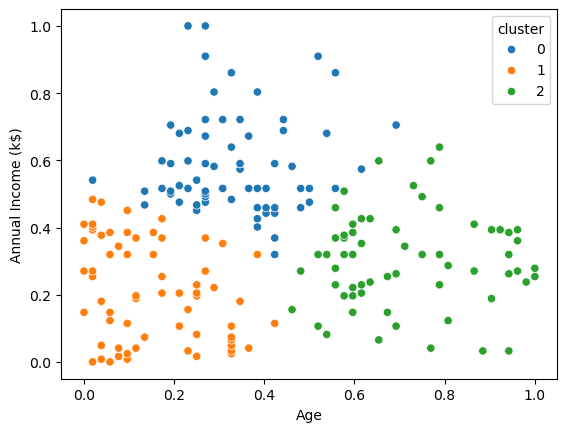

In [29]:
sns.scatterplot(
    data = data_copy,
    x = "Age",
    y = "Annual Income (k$)",
    hue = "cluster",
    palette = "tab10"
)

In [30]:
from sklearn.metrics import silhouette_score
silhouette_score(data_copy, modelo.labels_)

np.float64(0.784763272896246)

C:\DanielaLopez\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\DanielaLopez\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\DanielaLopez\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\DanielaLopez\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chun

<Axes: >

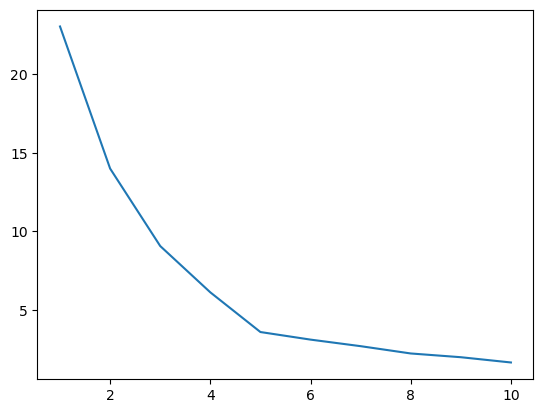

In [40]:
data_copy = data_normalizada.copy()
data_copy = data_normalizada[["Spending Score (1-100)", "Annual Income (k$)"]]

acum = []
for i in range(1,11):
    modelo = KMeans(
        n_clusters = i,
        n_init = 10, 
        max_iter = 300 
    )
    modelo.fit(data_copy)
    acum.append([i, modelo.inertia_])

sns.lineplot(x = np.array(acum)[:,0], y = np.array(acum)[:, 1])

C:\DanielaLopez\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: xlabel='Spending Score (1-100)', ylabel='Annual Income (k$)'>

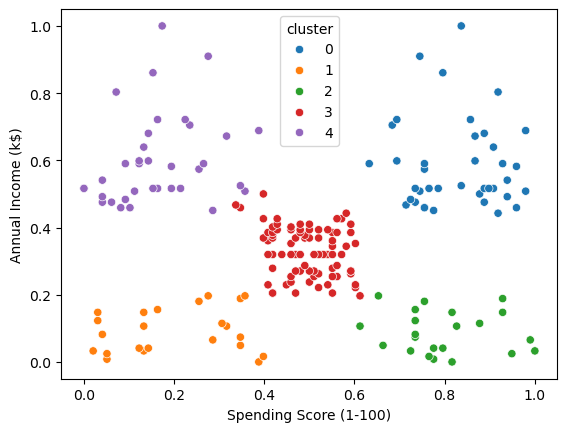

In [41]:
modelo = KMeans(
    n_clusters = 5,
    n_init = 10, 
    max_iter = 300 
)
modelo.fit(data_copy)

data_copy["cluster"] = modelo.labels_

sns.scatterplot(
    data = data_copy,
    x = "Spending Score (1-100)",
    y = "Annual Income (k$)",
    hue = "cluster",
    palette = "tab10"
)

In [42]:
silhouette_score(data_copy, modelo.labels_)

np.float64(0.855517049938369)

C:\DanielaLopez\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\DanielaLopez\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\DanielaLopez\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\DanielaLopez\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chun

<Axes: >

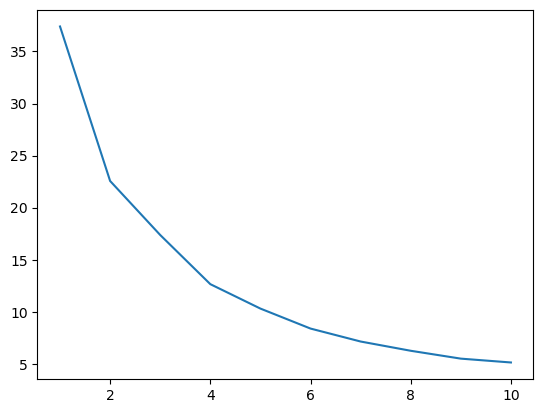

In [43]:
data_copy = data_normalizada.copy()

acum = []
for i in range(1,11):
    modelo = KMeans(
        n_clusters = i,
        n_init = 10, 
        max_iter = 300 
    )
    modelo.fit(data_copy)
    acum.append([i, modelo.inertia_])

sns.lineplot(x = np.array(acum)[:,0], y = np.array(acum)[:, 1])

In [44]:
modelo = KMeans(
    n_clusters = 4,
    n_init = 10, 
    max_iter = 300 
)
modelo.fit(data_copy)

data_copy["cluster"] = modelo.labels_

C:\DanielaLopez\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [45]:
silhouette_score(data_copy, modelo.labels_)

np.float64(0.7281587052665606)

In [46]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [49]:
data["cluster"] = modelo.labels_
data.iloc[:,2:].groupby("cluster").mean()

,Age,Annual Income (k$),Spending Score (1-100)
cluster,,,
0,39.368421,86.500000,19.578947
1,32.875000,86.100000,81.525000
2,25.438596,40.000000,60.298246
3,53.984615,47.707692,39.969231


In [51]:
mapping = {
    0: "Edad intermedia - ingresos altos - gasto bajo",
    1: "Edad intermedia - ingresos altos - gasto alto",
    2: "Jóvenes - ingresos bajos - gasto alto",
    3: "Mayores - ingresos moderados - gasto moderado "
}

In [52]:
data_copy["nombre_cluster"] = data_copy["cluster"].replace(mapping)
data_copy

,Age,Annual Income (k$),Spending Score (1-100),cluster,nombre_cluster
0,0.019231,0.000000,0.387755,2,Jóvenes - ingresos bajos - gasto alto
1,0.057692,0.000000,0.816327,2,Jóvenes - ingresos bajos - gasto alto
2,0.038462,0.008197,0.051020,2,Jóvenes - ingresos bajos - gasto alto
3,0.096154,0.008197,0.775510,2,Jóvenes - ingresos bajos - gasto alto
4,0.250000,0.016393,0.397959,2,Jóvenes - ingresos bajos - gasto alto
...,...,...,...,...,...
195,0.326923,0.860656,0.795918,1,Edad intermedia - ingresos altos - gasto alto
196,0.519231,0.909836,0.275510,0,Edad intermedia - ingresos altos - gasto bajo
197,0.269231,0.909836,0.744898,1,Edad intermedia - ingresos altos - gasto alto
198,0.269231,1.000000,0.173469,0,Edad intermedia - ingresos altos - gasto bajo
